In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)      # Mean
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)  # Log-variance

        # Decoder
        self.fc3 = nn.Linear(latent_dim, hidden_dim)
        self.fc4 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)  # Sample epsilon
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return torch.sigmoid(self.fc4(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar


In [2]:
def vae_loss(recon_x, x, mu, logvar):
    BCE = F.binary_cross_entropy(recon_x, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD


In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Hyperparameters
batch_size = 128
epochs = 10
latent_dim = 20
lr = 1e-3

# Data
transform = transforms.ToTensor()
train_loader = DataLoader(datasets.MNIST('/content/drive/MyDrive/Model/data', train=True, download=True, transform=transform),
                          batch_size=batch_size, shuffle=True)
test_loader = DataLoader(datasets.MNIST('/content/drive/MyDrive/Model/data', train=False, transform=transform),
                         batch_size=batch_size, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VAE(latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)


In [4]:
best_loss = float('inf')
save_path = 'best_vae_model.pth'

model.train()
for epoch in range(epochs):
    train_loss = 0
    for x, _ in train_loader:
        x = x.view(-1, 28*28).to(device)
        optimizer.zero_grad()
        recon_x, mu, logvar = model(x)
        loss = vae_loss(recon_x, x, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

    # Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), save_path)
        print(f"Best model saved at epoch {epoch+1} with loss {best_loss:.4f}")



Epoch 1, Loss: 164.5187
Best model saved at epoch 1 with loss 164.5187
Epoch 2, Loss: 121.5587
Best model saved at epoch 2 with loss 121.5587
Epoch 3, Loss: 114.8601
Best model saved at epoch 3 with loss 114.8601
Epoch 4, Loss: 111.9561
Best model saved at epoch 4 with loss 111.9561
Epoch 5, Loss: 110.1845
Best model saved at epoch 5 with loss 110.1845
Epoch 6, Loss: 108.9924
Best model saved at epoch 6 with loss 108.9924
Epoch 7, Loss: 108.1042
Best model saved at epoch 7 with loss 108.1042
Epoch 8, Loss: 107.4235
Best model saved at epoch 8 with loss 107.4235
Epoch 9, Loss: 106.9185
Best model saved at epoch 9 with loss 106.9185
Epoch 10, Loss: 106.4877
Best model saved at epoch 10 with loss 106.4877


In [5]:
# Make sure to initialize the model with same architecture
model = VAE(latent_dim=latent_dim).to(device)
model.load_state_dict(torch.load('best_vae_model.pth'))
model.eval()


VAE(
  (fc1): Linear(in_features=784, out_features=400, bias=True)
  (fc_mu): Linear(in_features=400, out_features=20, bias=True)
  (fc_logvar): Linear(in_features=400, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=400, bias=True)
  (fc4): Linear(in_features=400, out_features=784, bias=True)
)

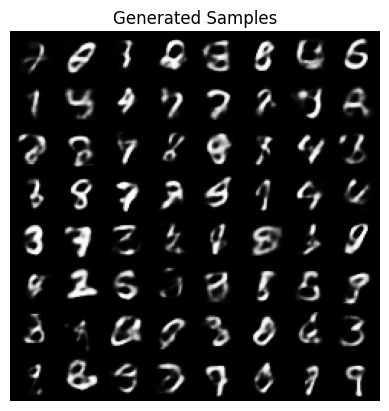

In [8]:
import torchvision
model.eval()

with torch.no_grad():
    z = torch.randn(64, latent_dim).to(device)
    generated = model.decode(z).cpu().view(-1, 1, 28, 28)

    # Show generated images
    grid_img = torchvision.utils.make_grid(generated, nrow=8)
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.title("Generated Samples")
    plt.axis("off")
    plt.show()


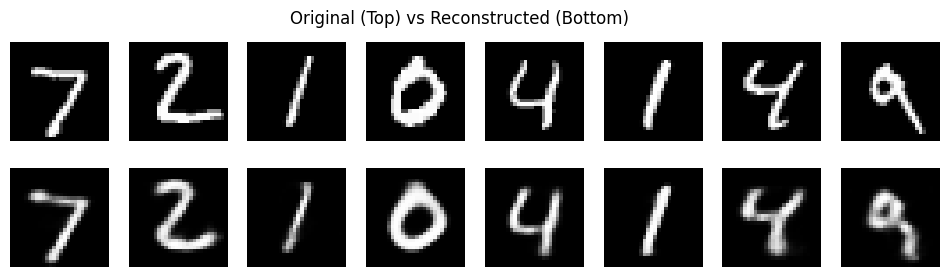

In [7]:
# Visualize reconstruction on test images
with torch.no_grad():
    x, _ = next(iter(test_loader))
    x = x.view(-1, 28*28).to(device)
    recon_x, _, _ = model(x)
    x = x.view(-1, 1, 28, 28).cpu()
    recon_x = recon_x.view(-1, 1, 28, 28).cpu()

    fig, axes = plt.subplots(2, 8, figsize=(12, 3))
    for i in range(8):
        axes[0, i].imshow(x[i][0], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_x[i][0], cmap='gray')
        axes[1, i].axis('off')
    plt.suptitle('Original (Top) vs Reconstructed (Bottom)')
    plt.show()
